In [26]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

In [27]:
from functools import partial

from IPython.display import display, Markdown, Image
from statsforecast import StatsForecast
from statsforecast.models import AutoETS
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, mape, mase

# 8.1 Simple exponential smoothing

It may be sensible to attach larger weights to more recent observations than to observations from the distant past. This is exactly the concept behind simple exponential smoothing. Forecasts are calculated using weighted averages, where the weights decrease exponentially as observations come from further in the past — the smallest weights are associated with the oldest observations:

$\hat{y}_{T+1|T} = \alpha y_T + \alpha(1-\alpha)y_{T-1} + \alpha(1-\alpha)^2y_{T-2} + \cdots$

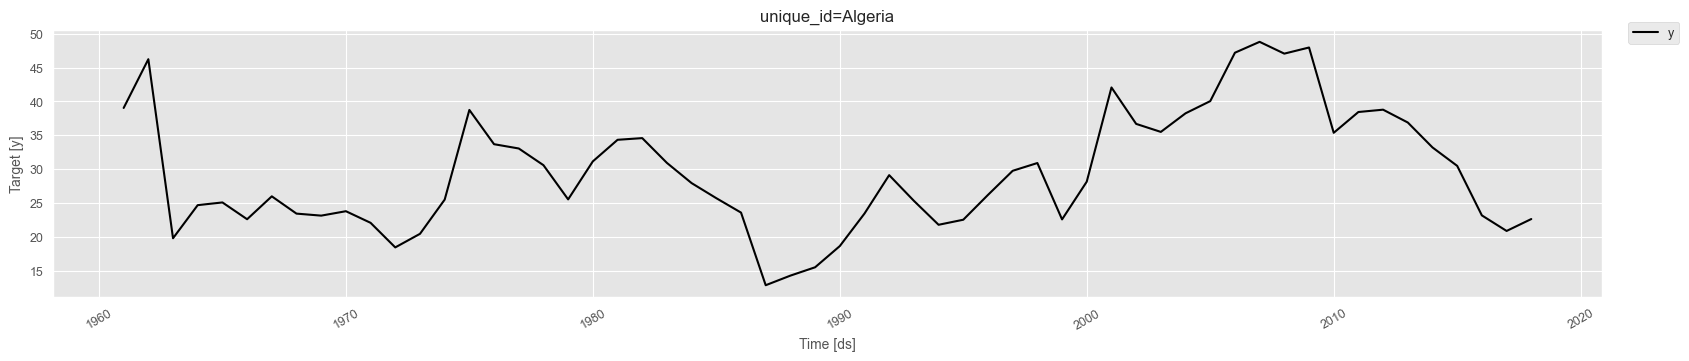

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from utilsforecast.plotting import plot_series

algeria_economy = pd.read_csv("../data/fpp3/algeria_exports.csv",
    parse_dates=["ds"])
plt.rcParams["figure.figsize"] = (8, 4.3)
plot_series(algeria_economy)

In [29]:
sf = StatsForecast(freq="YE",
    models=[AutoETS(model="ANN", alias="SES")])

fc = sf.forecast(df=algeria_economy, h=5, level=[80, 95], fitted=True)
fc.head()

,unique_id,ds,SES,SES-lo-95,SES-lo-80,SES-hi-80,SES-hi-95
0,Algeria,2018-12-31,22.442,10.523,14.648,30.235,34.361
1,Algeria,2019-12-31,22.442,6.875,12.263,32.620,38.009
2,Algeria,2020-12-31,22.442,3.933,10.339,34.544,40.951
3,Algeria,2021-12-31,22.442,1.398,8.682,36.202,43.486
4,Algeria,2022-12-31,22.442,-0.863,7.204,37.680,45.746


In [30]:
fitted_vals = sf.forecast_fitted_values()
fitted_vals.head()

,unique_id,ds,y,SES,SES-lo-95,SES-lo-80,SES-hi-80,SES-hi-95
0,Algeria,1960-12-31,39.043,39.530,27.720,31.808,47.252,51.340
1,Algeria,1961-12-31,46.245,39.121,27.311,31.399,46.843,50.931
2,Algeria,1962-12-31,19.794,45.105,33.295,37.383,52.828,56.916
3,Algeria,1963-12-31,24.685,23.842,12.031,16.119,31.564,35.652
4,Algeria,1964-12-31,25.084,24.550,12.740,16.828,32.272,36.360


In [31]:
# Save model fit(s)
sf.fit(algeria_economy)
# Save model fit(s) and return forecasts
fc = sf.fit_predict(df=algeria_economy, h=5, level=[80, 95])
params = sf.fitted_[0, 0].model_["fit"].x
alpha, level_0 = np.round(params, 4)

In [32]:
ses = AutoETS(model="ANN", alias="SES")
ses.fit(y=algeria_economy["y"].values)
params = ses.model_["fit"].x
alpha, level_0 = np.round(params, 4)
print("Optimal parameters:")
print("alpha:", alpha)
print("Initial level:", level_0)

Optimal parameters:
alpha: 0.8401
Initial level: 39.53


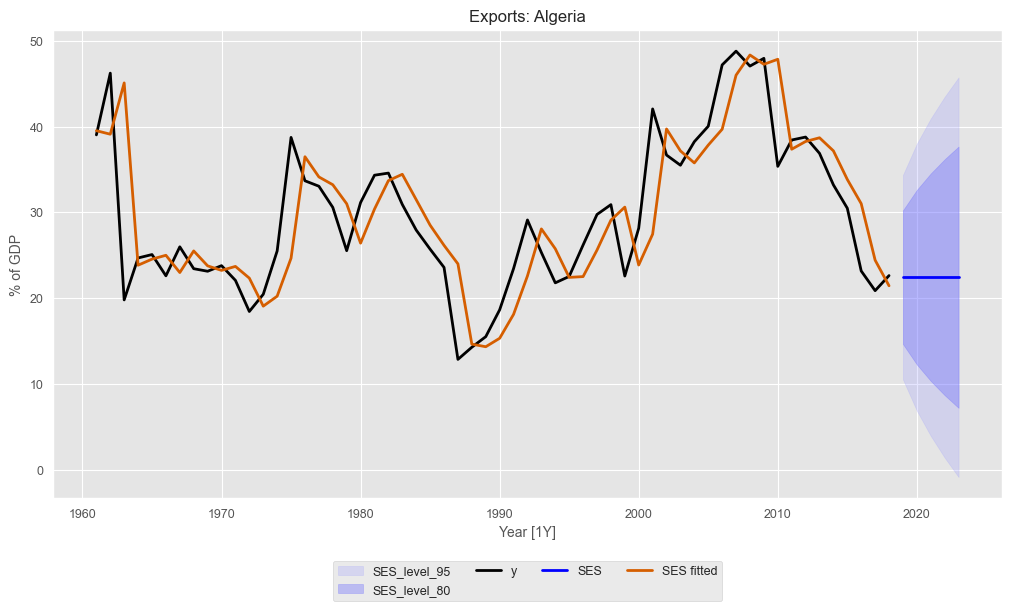

In [33]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# 95% interval
ax.fill_between(
    fc["ds"],
    fc["SES-lo-95"],
    fc["SES-hi-95"],
    color="#9999FF",
    alpha=0.25,
    label="SES_level_95",
)

# 80% interval
ax.fill_between(
    fc["ds"],
    fc["SES-lo-80"],
    fc["SES-hi-80"],
    color="#6666FF",
    alpha=0.35,
    label="SES_level_80",
)

# Actual
ax.plot(
    algeria_economy["ds"],
    algeria_economy["y"],
    color="black",
    linewidth=2,
    label="y",
)

# Forecast
ax.plot(
    fc["ds"],
    fc["SES"],
    color="blue",
    linewidth=2,
    label="SES",
)

# Fitted values
ax.plot(
    fitted_vals["ds"],
    fitted_vals["SES"],
    color="#D55E00",  # same orange as textbook
    linewidth=2,
    label="SES fitted",
)

ax.set_title("Exports: Algeria")
ax.set_xlabel("Year [1Y]")
ax.set_ylabel("% of GDP")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=4,
)

plt.show()

# 8.2 Methods with trend

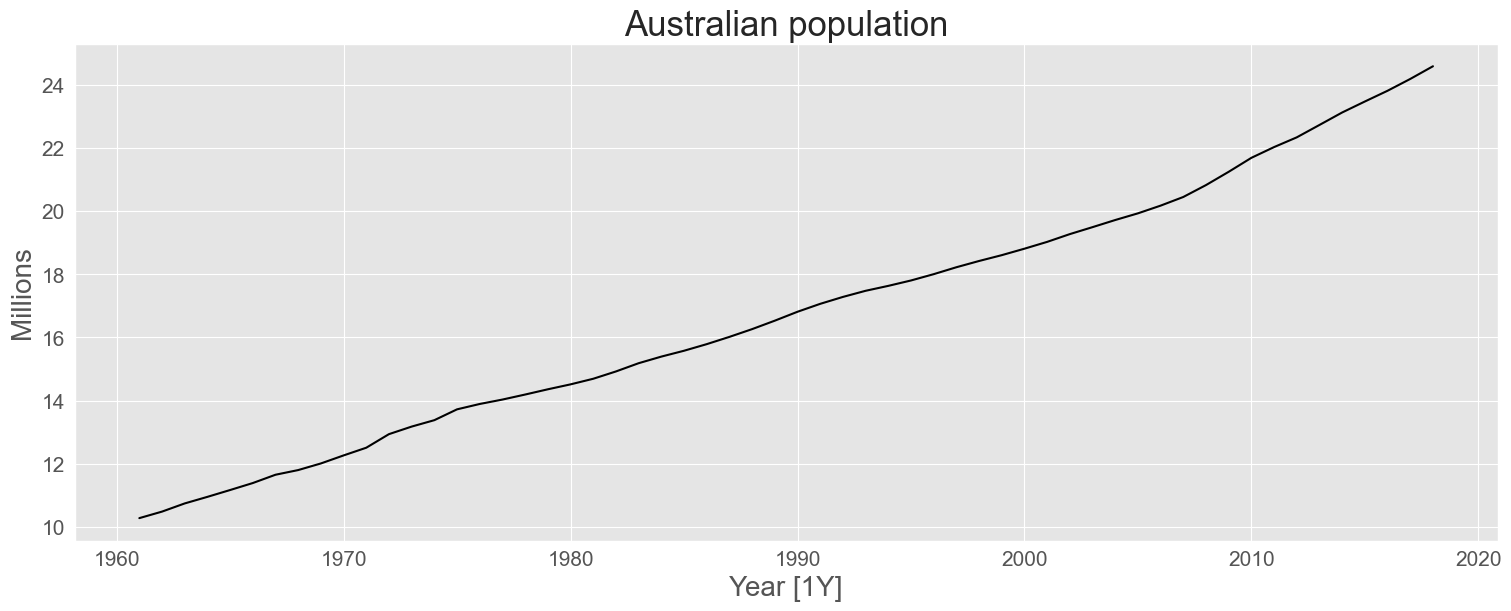

In [34]:
aus_economy = (
    pd.read_csv("../data/fpp3/aus_economy.csv", parse_dates=["ds"])
    .assign(y=lambda x: x["y"] / 1e6)
)

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(aus_economy["ds"], aus_economy["y"], color="#000000", linewidth=1.5)
ax.set_title("Australian population", fontsize=25)
ax.set_xlabel("Year [1Y]", fontsize=20)
ax.set_ylabel("Millions", fontsize=20)
ax.tick_params(axis="both", labelsize=15)
plt.show()

In [35]:
sf = StatsForecast(models=[AutoETS(model="AAN", alias="Holt")], freq="YE")
fc = sf.fit_predict(df=aus_economy, h=10)

In [36]:
holt = sf.fitted_[0, 0]
params = np.round(holt.model_["fit"].x, 4)
print("Optimal parameters:")
print("alpha:", params[0])
print("beta:", params[1])
print("Initial level:", params[2])
print("Initial trend:", params[3])

Optimal parameters:
alpha: 0.9999
beta: 0.2001
Initial level: 10.0509
Initial trend: 0.2264


In [37]:
sf = StatsForecast(
  models=[
    AutoETS(model="AAN", alias="Holt"),
    AutoETS(model="AAN", alias="Damped Holt's method",
      damped=True, phi=0.9),
  ],
  freq="YE",
)
fc = sf.forecast(df=aus_economy, h=15)

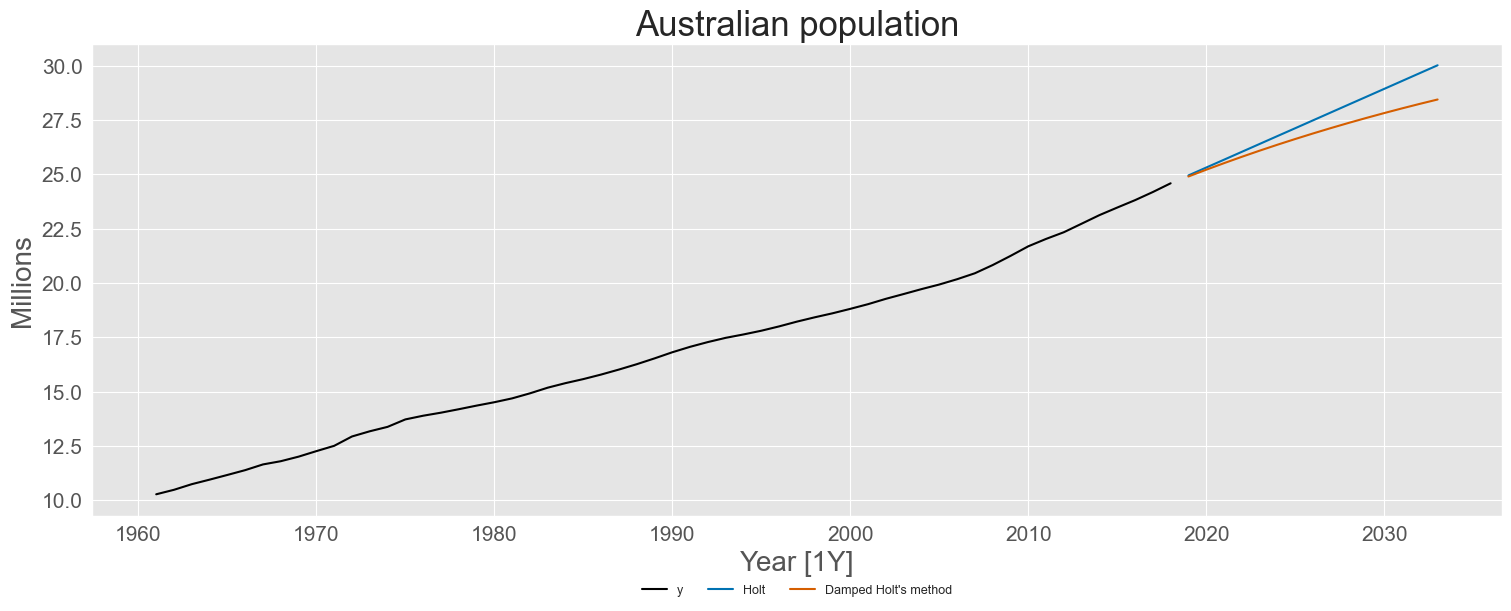

In [38]:
fig, ax = plt.subplots(figsize=(15, 6))

# Actual series
ax.plot(
    aus_economy["ds"],
    aus_economy["y"],
    color="#000000",
    linewidth=1.5,
    label="y",
)

# Forecasts
ax.plot(
    fc["ds"],
    fc["Holt"],
    color="#0072B2",
    linewidth=1.5,
    label="Holt",
)
ax.plot(
    fc["ds"],
    fc["Damped Holt's method"],
    color="#D55E00",
    linewidth=1.5,
    label="Damped Holt's method",
)

ax.set_title("Australian population", fontsize=25)
ax.set_xlabel("Year [1Y]", fontsize=20)
ax.set_ylabel("Millions", fontsize=20)
ax.tick_params(axis="both", labelsize=15)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=False,
)

plt.show()

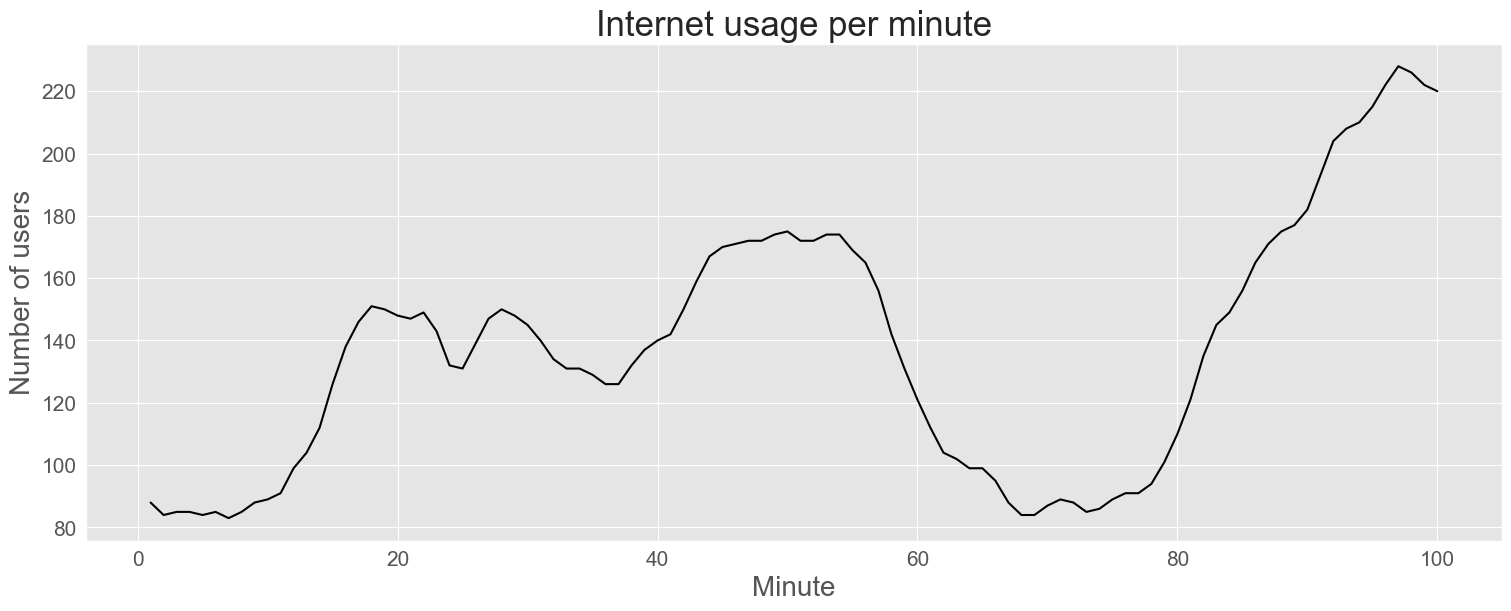

In [39]:
www_usage = pd.read_csv("../data/fpp3/www_usage.csv")

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(www_usage["ds"], www_usage["y"], color="#000000", linewidth=1.5)
ax.set_title("Internet usage per minute", fontsize=25)
ax.set_xlabel("Minute", fontsize=20)
ax.set_ylabel("Number of users", fontsize=20)
ax.tick_params(axis="both", labelsize=15)
plt.show()

In [40]:
from utilsforecast.losses import mape as _mape
def mape(df, models, id_col = "unique_id", target_col = "y"):
    """MAPE scaled to percentage."""
    df_mape = _mape(df, models, id_col=id_col, target_col=target_col)
    df_mape.loc[:, df_mape.select_dtypes(include='number').columns] *= 100
    return df_mape

sf = StatsForecast(
    models=[
        AutoETS(model="ANN", alias="SES"),
        AutoETS(model="AAN", alias="Holt"),
        AutoETS(model="AAN", damped=True, phi=0.9, alias="Damped"),
    ],
    freq=1,
)
cv = sf.cross_validation(df=www_usage, h=1, n_windows=90, step_size=1)
result_df = evaluate(
    cv.drop("cutoff", axis=1),
    metrics=[rmse, mae, mape, partial(mase, seasonality=1)],
    train_df=www_usage,
)
(result_df.drop(columns="unique_id")
    .set_index("metric").T
    .rename(columns=str.upper))

metric,RMSE,MAE,MAPE,MASE
SES,6.072,4.849,3.588,1.072
Holt,5.086,4.181,3.164,0.924
Damped,5.037,4.057,3.058,0.896


In [41]:
sf = StatsForecast(
    models=[AutoETS(model="AAN", damped=True, alias="Damped")],
    freq=1,
)
sf.fit(www_usage)
params = np.round(sf.fitted_[0, 0].model_["fit"].x, 4)
print("Optimal parameters:")
print("Damped alpha:", params[0])
print("Damped beta:", params[1])
print("Damped phi:", params[2])
print("Initial level:", params[3])
print("Initial trend:", params[4])

Optimal parameters:
Damped alpha: 0.9999
Damped beta: 0.2
Damped phi: 0.9087
Initial level: 88.8688
Initial trend: -0.9231


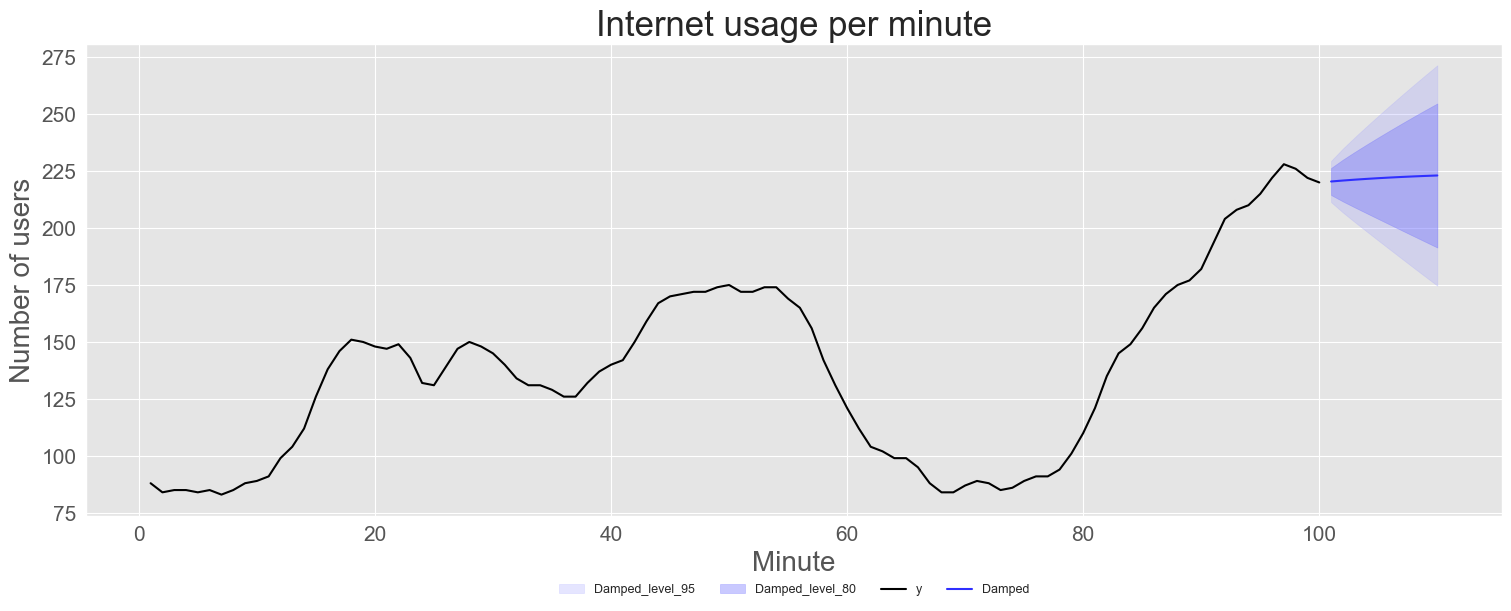

In [42]:
level = [80, 95]
fc = sf.predict(h=10, level=level)

fig, ax = plt.subplots(figsize=(15, 6))

# 95% interval
ax.fill_between(
    fc["ds"],
    fc["Damped-lo-95"],
    fc["Damped-hi-95"],
    color="#9999FF",
    alpha=0.25,
    label="Damped_level_95",
)

# 80% interval
ax.fill_between(
    fc["ds"],
    fc["Damped-lo-80"],
    fc["Damped-hi-80"],
    color="#6666FF",
    alpha=0.35,
    label="Damped_level_80",
)

# Actual
ax.plot(
    www_usage["ds"],
    www_usage["y"],
    color="#000000",
    linewidth=1.5,
    label="y",
)

# Forecast
ax.plot(
    fc["ds"],
    fc["Damped"],
    color="#2f2fff",
    linewidth=1.5,
    label="Damped",
)

ax.set_title("Internet usage per minute", fontsize=25)
ax.set_xlabel("Minute", fontsize=20)
ax.set_ylabel("Number of users", fontsize=20)
ax.tick_params(axis="both", labelsize=15)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=4,
    frameon=False,
)

plt.show()

# 8.3 Methods with seasonality

In [43]:
tourism = (
    pd.read_csv("../data/tsibble/tourism.csv")
    .assign(
        ds=lambda x: pd.PeriodIndex(
            x["Quarter"].str.replace(" ", "", regex=False), freq="Q"
        ).to_timestamp(how="end"),
        y=lambda x: x["Trips"],
    )
)

aus_holidays = (
    tourism.loc[lambda x: x["Purpose"] == "Holiday"]
    .rename(columns={"Purpose": "unique_id"})
    .groupby(["unique_id", "ds"])["y"]
    .sum()
    .div(1e3)
    .reset_index()
)

sf = StatsForecast(
    models=[
        AutoETS(season_length=4, model="AAA", alias="additive"),
        AutoETS(season_length=4, model="MAM", alias="multiplicative"),
    ],
    freq="QE",
)
fc = sf.forecast(df=aus_holidays, h=12, fitted=True)

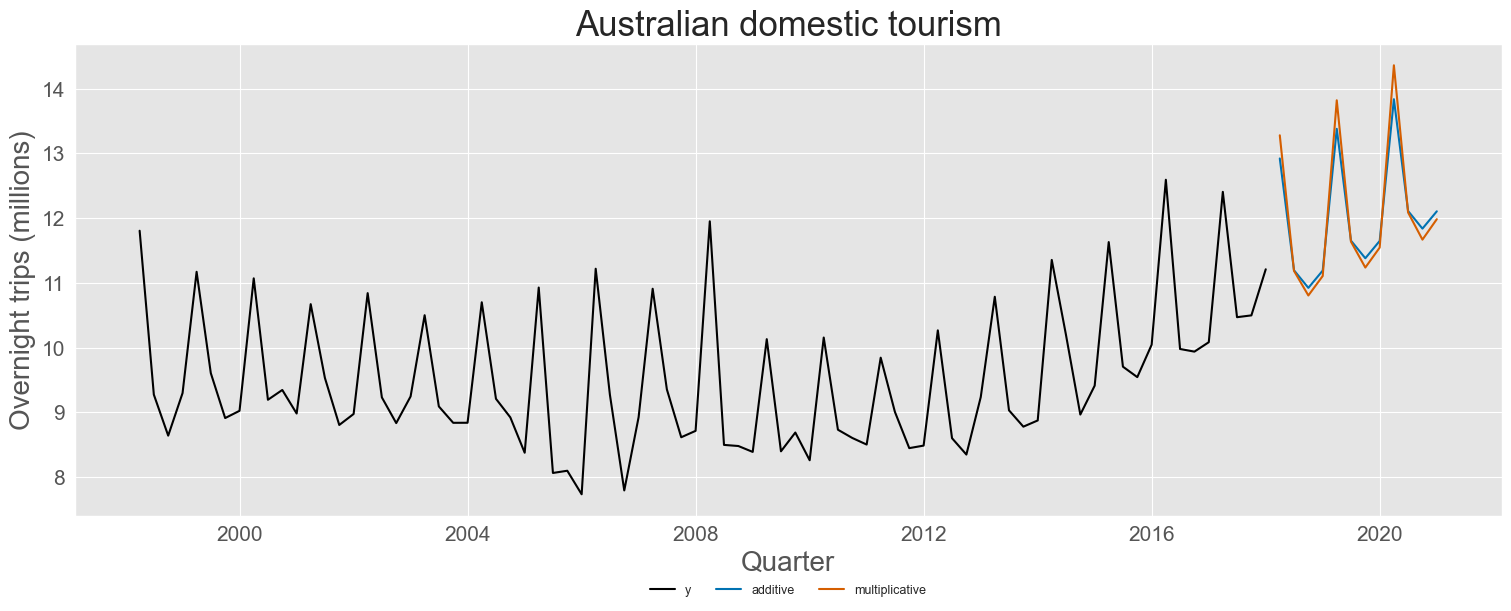

In [44]:
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    aus_holidays["ds"],
    aus_holidays["y"],
    color="#000000",
    linewidth=1.5,
    label="y",
)
ax.plot(
    fc["ds"],
    fc["additive"],
    color="#0072B2",
    linewidth=1.5,
    label="additive",
)
ax.plot(
    fc["ds"],
    fc["multiplicative"],
    color="#D55E00",
    linewidth=1.5,
    label="multiplicative",
)

ax.set_title("Australian domestic tourism", fontsize=25)
ax.set_xlabel("Quarter", fontsize=20)
ax.set_ylabel("Overnight trips (millions)", fontsize=20)
ax.tick_params(axis="both", labelsize=15)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=False,
)

plt.show()

In [45]:
fitted_vals = sf.forecast_fitted_values()
evaluate(fitted_vals, metrics=[rmse])

,unique_id,metric,additive,multiplicative
0,Holiday,rmse,0.412,0.412


In [46]:
sf.fit(aus_holidays)
for model in sf.fitted_[0]:
    print(model)
    # parameters: [alpha, beta, gamma, phi, l0, (b0 if trend), s1, ..., sm]
    par = model.model_["par"]
    components = model.model_["components"]
    trendtype = components[1]
    alpha, beta, gamma = np.round(par[:3], 4)
    level_0 = np.round(par[4], 4)
    seasonal_start = 4 + 1 + (1 if trendtype != "N" else 0)
    seasonal = np.round(par[seasonal_start:], 4)
    print("  Optimal parameters:")
    print("  alpha:", alpha)
    print("  beta:", beta)
    print("  gamma:", gamma)
    print("  Initial level:", level_0)
    print("  Initial seasonal components:", seasonal)
    print("  Sum of seasonal components:", seasonal.sum())

additive
  Optimal parameters:
  alpha: 0.2325
  beta: 0.03
  gamma: 0.0001
  Initial level: 9.8372
  Initial seasonal components: [-0.5386 -0.6916 -0.3051  1.5353]
  Sum of seasonal components: 2.220446049250313e-16
multiplicative
  Optimal parameters:
  alpha: 0.239
  beta: 0.0274
  gamma: 0.0008
  Initial level: 9.8161
  Initial seasonal components: [0.9429 0.9265 0.9688 1.1618]
  Sum of seasonal components: 4.0


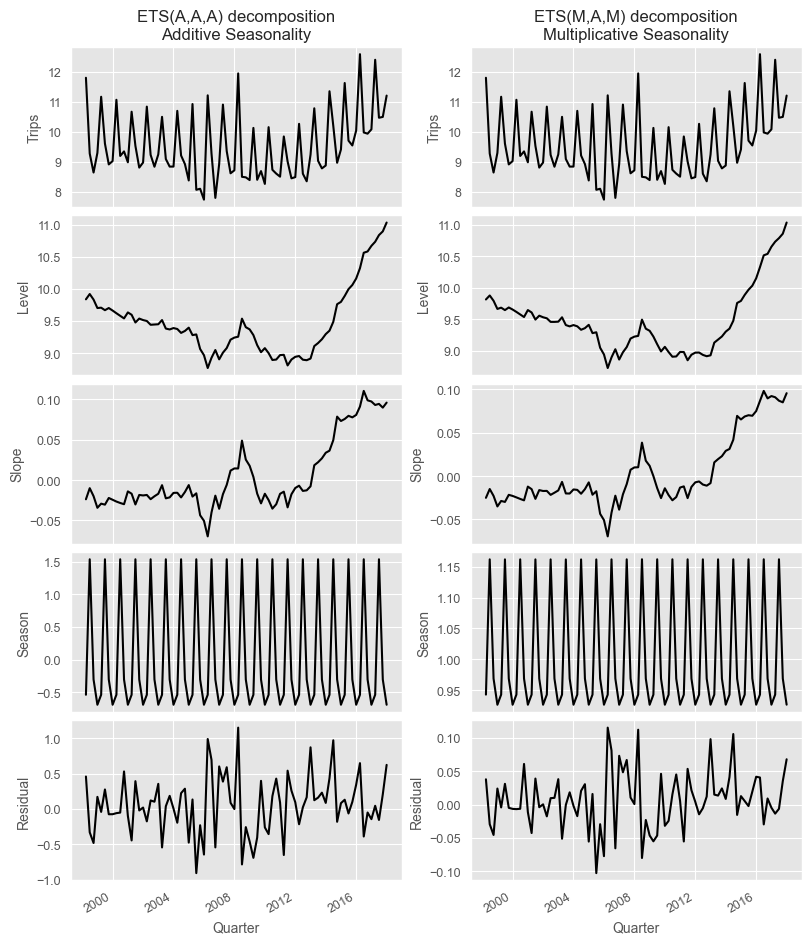

In [47]:
titles = [
    "ETS(A,A,A) decomposition\nAdditive Seasonality",
    "ETS(M,A,M) decomposition\nMultiplicative Seasonality",
]
states = ["Level", "Slope", "Season"]

fig, all_axes = plt.subplots(5, 2, figsize=(8, 8*14/12), sharex=True)
for (axes, title, model) in zip(all_axes.T, titles, sf.fitted_[0]):
    states = model.model_["states"]
    df = pd.DataFrame({
        "Trips": aus_holidays["y"].to_numpy(),
        "Level": states[:, 0][:-1],
        "Slope": states[:, 1][:-1],
        "Season": states[:, 2][:-1],
        "Residual": model.model_["residuals"],
        "Quarter": aus_holidays["ds"].to_numpy(),
    }).set_index("Quarter")
    for (ax, column) in zip(axes, df.columns):
        df[column].plot(ax=ax, ylabel=column)
    axes[0].set(title=title)

In [48]:
sth_cross_ped = (
    pd.read_csv("../data/tsibble/pedestrian.csv")
    .rename(columns={"Sensor": "unique_id", "Date": "ds", "Count": "y"})
    .assign(ds=lambda x: pd.to_datetime(x["ds"]))
    .loc[
        lambda x: (x["unique_id"] == "Southern Cross Station")
        & (x["ds"].between("2016-07-01", "2016-08-14"))
    ]
    .groupby(["unique_id", "ds"])["y"]
    .sum()
    .div(1e3)
    .reset_index()
)

train = sth_cross_ped.loc[lambda x: x["ds"] < "2016-08-01"]

sf = StatsForecast(
    models=[
        AutoETS(
            season_length=7,
            model="MAM",
            damped=True,
            alias="HW Damped",
        )
    ],
    freq="D",
)

level = [80, 95]
fc = sf.forecast(df=train, h=14, level=level)

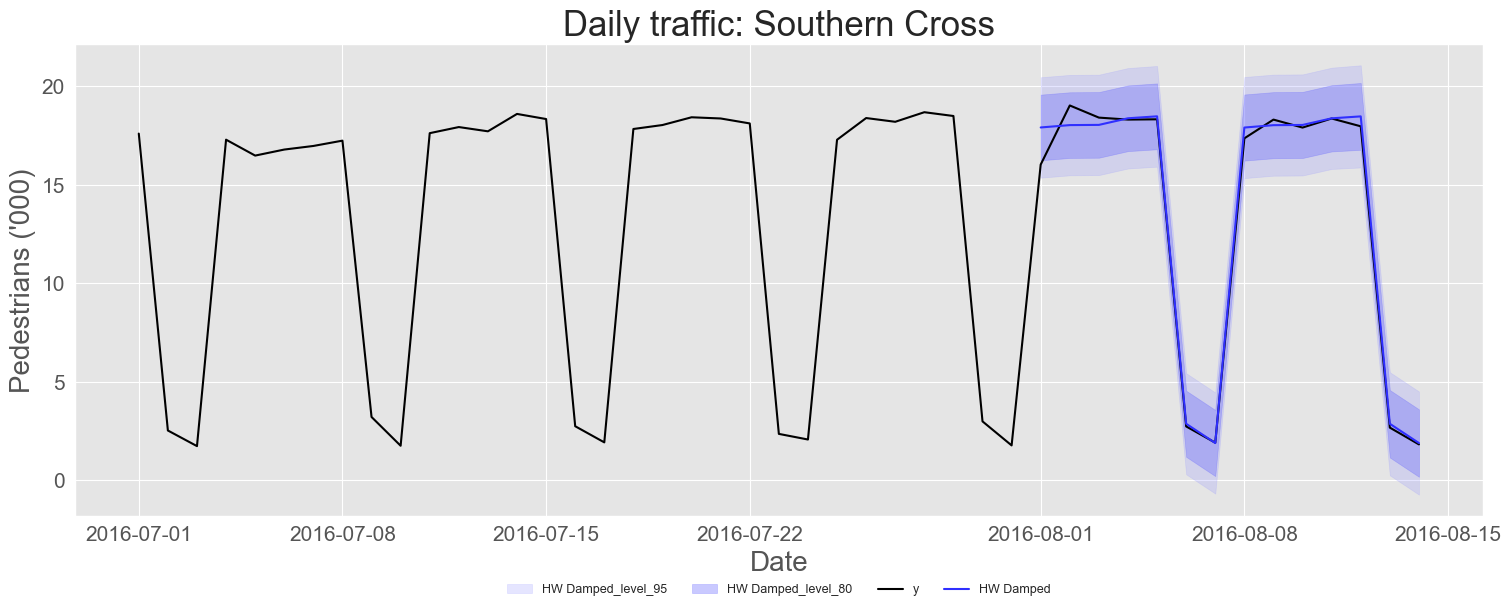

In [49]:
fig, ax = plt.subplots(figsize=(15, 6))

# 95% interval
ax.fill_between(
    fc["ds"],
    fc["HW Damped-lo-95"],
    fc["HW Damped-hi-95"],
    color="#9999FF",
    alpha=0.25,
    label="HW Damped_level_95",
)

# 80% interval
ax.fill_between(
    fc["ds"],
    fc["HW Damped-lo-80"],
    fc["HW Damped-hi-80"],
    color="#6666FF",
    alpha=0.35,
    label="HW Damped_level_80",
)

# Actual (full window for context)
ax.plot(
    sth_cross_ped["ds"],
    sth_cross_ped["y"],
    color="#000000",
    linewidth=1.5,
    label="y",
)

# Forecast
ax.plot(
    fc["ds"],
    fc["HW Damped"],
    color="#2f2fff",
    linewidth=1.5,
    label="HW Damped",
)

ax.set_title("Daily traffic: Southern Cross", fontsize=25)
ax.set_xlabel("Date", fontsize=20)
ax.set_ylabel("Pedestrians ('000)", fontsize=20)
ax.tick_params(axis="both", labelsize=15)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=4,
    frameon=False,
)

plt.show()

# 8.5 Innovation state space models

# 8.6 Estimation and model selection

In [50]:
sf = StatsForecast(models=[AutoETS(season_length=4)], freq="Q")
sf.fit(aus_holidays)
autoets = sf.fitted_[0, 0]
model = autoets.model_
model["method"]

'ETS(M,N,M)'

In [ ]:
params = np.round(autoets.model_["fit"].x, 4)
print("Optimal parameters:")
print("alpha:", params[0])
print("gamma:", params[1])
print("Initial level for series:", params[2])
print("Initial seasonal components:", params[3:])

Optimal parameters:
alpha: 0.3612
gamma: 0.0001
Initial level for series: 9.7878
Initial seasonal components: [0.9432 0.9268 0.9683]


"The automatically selected model is ETS(M,N,M), indicating multiplicative errors, no trend, and multiplicative seasonality. The data exhibits a stable seasonal pattern but no long-term upward or downward trend. The estimated smoothing parameter α = 0.3612 means the level is updated moderately using new observations, while γ ≈ 0 indicates the seasonal pattern changes very little over time. The seasonal effects are proportional to the level of the series rather than fixed amounts."

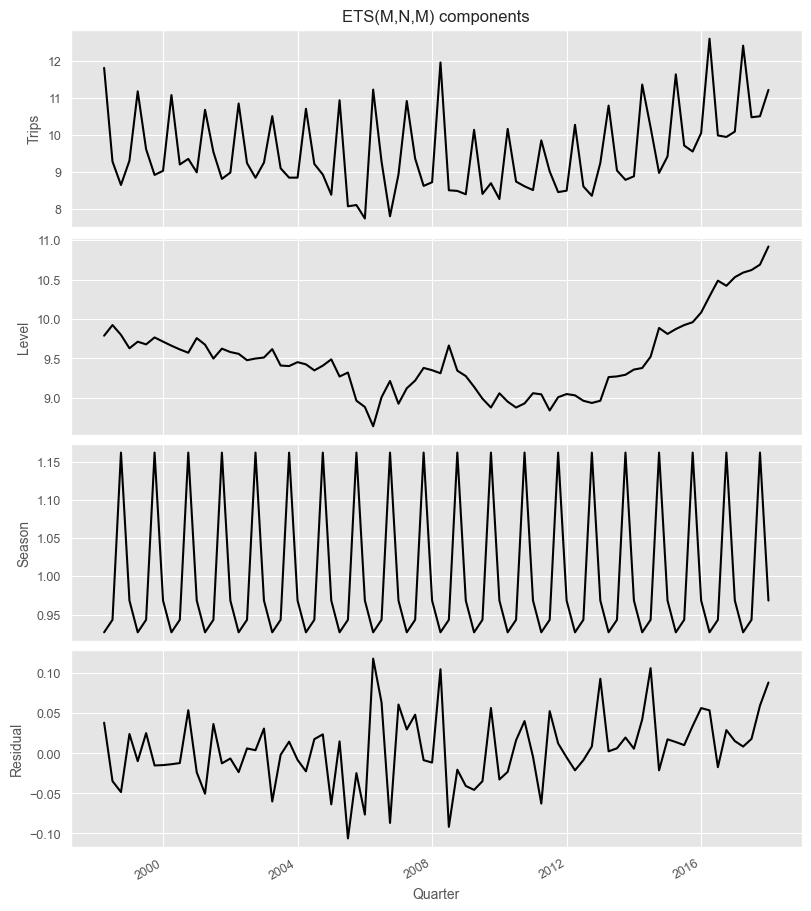

In [52]:
states = model["states"]
df = pd.DataFrame({
    "Trips": aus_holidays["y"].to_numpy(),
    "Level": states[:, 0][:-1],
    "Season": states[:, 2][:-1],
    "Residual": model["residuals"],
    "Quarter": aus_holidays["ds"].to_numpy(),
}).set_index("Quarter")
fig, axes = plt.subplots(4, 1, figsize=(8, 9), sharex=True)
for (ax, column) in zip(axes, df.columns):
    df[column].plot(ax=ax, ylabel=column)
axes[0].set(title="ETS(M,N,M) components")
plt.show()

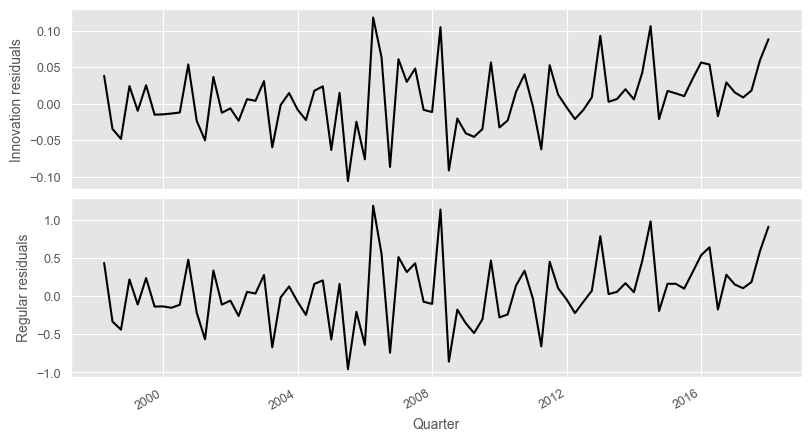

In [53]:
df = pd.DataFrame({
    "Innovation residuals": autoets.model_["residuals"],
    "Regular residuals": autoets.model_["actual_residuals"],
    "Quarter": aus_holidays["ds"].to_numpy(),
}).set_index("Quarter")
fig, axes = plt.subplots(2, 1, sharex=True)
for (ax, column) in zip(axes, df.columns):
    df[column].plot(ax=ax, ylabel=column)
plt.show()

# 8.7